# Magnetic Phase Modulation

This notebook demonstrates Magnetic-PyMS's magnetic phase modulation feature: an
Aharonov-Bohm phase shift imprinted on the electron wavefunction by the in-plane
component of a specimen's atomic magnetic moments, in addition to the usual
electrostatic phase.

**Physical background (brief).** For a beam travelling along z through a
magnetized specimen, the relevant magnetic contribution to the (paraxial) phase
grating is `exp[-i (e/hbar) integral(A_z dz)]`, where `A_z` is the z-component of
the magnetic vector potential produced by the specimen's magnetization. Only the
**in-plane** magnetic moment components (mx, my) contribute to `A_z` -- a moment
purely along the beam direction (mz) contributes exactly zero, a standard result
for collinear magnetism (see e.g. Edstrom, Lubk & Rusz, *Magnetic effects in the
paraxial regime of elastic electron scattering*, Phys. Rev. B 94, 174414 (2016)).
This is one specific channel of the full magnetic Pauli-equation Hamiltonian
(there are others -- spin-field coupling and an in-plane-vector-potential term --
not yet implemented here); see the module docstrings in `structure_routines.py`
for the full scope and references.

**API surface.** Everything below builds on two additions to the existing
`pyms.structure_routines.structure` class:

- `structure(unitcell, atoms, dwf, magnetic_moments=...)` -- an optional,
  default-`None` `(natoms, 3)` array of Cartesian (mx, my, mz) moments in Bohr
  magnetons, alongside the same `atoms`/`dwf`/`unitcell` arguments every
  existing structure already takes.
- `structure.make_magnetic_potential(...)` -- the magnetic phase alone, with the
  same signature style as the existing `make_potential`.
- `structure.make_transmission_functions(..., include_magnetic=True)` -- the
  default-`True` flag that adds the magnetic phase into the ordinary
  electrostatic transmission function. A structure with no magnetic moment data
  (`magnetic_moments=None`, the default) is completely unaffected regardless of
  this flag -- every pre-existing, non-magnetic call site keeps working exactly
  as before.

Three worked examples follow: (1) the magnetic phase on its own, alongside the
electrostatic potential, for a single static slice; (2) how it enters the
combined transmission function; (3) its (small but real) effect on a
propagated exit wave. For further runnable examples, see the unit tests in
`tests/test_make_magnetic_potential.py` and
`tests/test_make_transmission_functions_magnetic.py`, which double as focused,
documented usage examples for edge cases (zero-net-moment structures, rotation
equivariance, backward compatibility with non-magnetic structures, and so on).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pyms.structure_routines import structure
from pyms.py_multislice import make_propagators, multislice
from pyms.Probe import plane_wave_illumination

## Example 1: a magnetic structure, and its magnetic phase alongside the electrostatic potential

We build a small hand-picked structure: six iron atoms in a 20x20x2 Angstrom
cell, with general (non-axis-aligned, nonzero-net) in-plane magnetic moments.
`dwf` (Debye-Waller factors) is required by `structure.__init__` but is only
ever read when `displacements=True` is passed to `make_potential`/
`make_magnetic_potential`; we use `displacements=False` throughout this
notebook for deterministic, reproducible output, so its value here doesn't
matter.

In [2]:
Z = 26  # Iron
unitcell = [20.0, 20.0, 2.0]  # Angstrom
pixels = [256, 256]
eV = 100e3  # 100 kV

# Fractional (in-plane, in-plane, depth) coordinates and atomic number per atom
atoms = np.array([
    [0.30, 0.20, 0.5, Z],
    [0.65, 0.45, 0.5, Z],
    [0.25, 0.70, 0.5, Z],
    [0.75, 0.15, 0.5, Z],
    [0.55, 0.60, 0.5, Z],
    [0.80, 0.85, 0.5, Z],
])
dwf = np.zeros(len(atoms))

# Cartesian (mx, my, mz) magnetic moment per atom, in Bohr magnetons -- general
# directions and magnitudes, deliberately with a nonzero net moment (more
# ferromagnet-like than a cancelling pair). Only mx, my contribute to the
# magnetic phase (see the module docstring above); mz is accepted and stored
# but has no effect on any quantity computed below.
moments = np.array([
    [0.8, 0.3, 0.0],
    [0.5, -0.6, 0.0],
    [-0.4, 0.7, 0.0],
    [0.9, 0.9, 0.0],
    [-0.7, -0.2, 0.0],
    [0.3, -0.5, 0.0],
])

fe_structure = structure(unitcell, atoms, dwf, magnetic_moments=moments)
print("is_magnetic:", fe_structure.is_magnetic)

is_magnetic: True


/home/claude/pyms_upstream/pyms/structure_routines.py:1370: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  kx = torch.from_numpy(kx_np).to(device).type(complexdtype)


electrostatic potential: max = 1385.4 (V.Angstrom)
magnetic phase:          max = 4.448e-05 rad


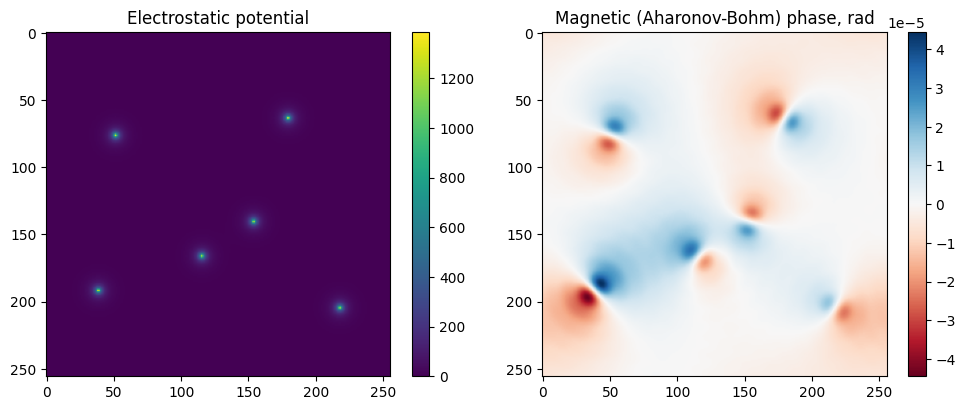

In [3]:
V = fe_structure.make_potential(pixels, displacements=False, dtype=torch.float64)
V = np.real(V.cpu().numpy())[0]

phi_mag = fe_structure.make_magnetic_potential(pixels, displacements=False, dtype=torch.float64)
phi_mag = np.real(phi_mag.cpu().numpy())[0]

print(f"electrostatic potential: max = {V.max():.1f} (V.Angstrom)")
print(f"magnetic phase:          max = {np.abs(phi_mag).max():.3e} rad")

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
im0 = ax[0].imshow(V, cmap="viridis")
ax[0].set_title("Electrostatic potential")
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(phi_mag, cmap="RdBu", vmin=-np.abs(phi_mag).max(), vmax=np.abs(phi_mag).max())
ax[1].set_title("Magnetic (Aharonov-Bohm) phase, rad")
plt.colorbar(im1, ax=ax[1])
plt.tight_layout()
plt.show()

Note the two panels' very different length scales: the electrostatic potential
peaks sharply at the atom cores (the familiar projected-Coulomb-potential
cusp), while the magnetic phase shows the smooth, four-lobed sign pattern of a
projected in-plane magnetic dipole field, centered on but vanishing *at* each
atom (a real physical feature of the point-dipole limit, not a rendering
artifact) -- and it is about five orders of magnitude smaller in magnitude.
Keep this scale difference in mind for the next two examples.

## Example 2: the combined transmission function

`make_transmission_functions(..., include_magnetic=True)` (the default) adds
the magnetic phase into the ordinary electrostatic transmission function
before exponentiating. Because the magnetic phase is so much smaller than the
electrostatic one, the two transmission functions' raw phase maps are
visually indistinguishable -- the difference has to be plotted directly to see
it at all.

transmission function shape: (1, 256, 256) -- (nsubslices, Y, X)
max phase difference (magnetic contribution): 4.461e-05 rad


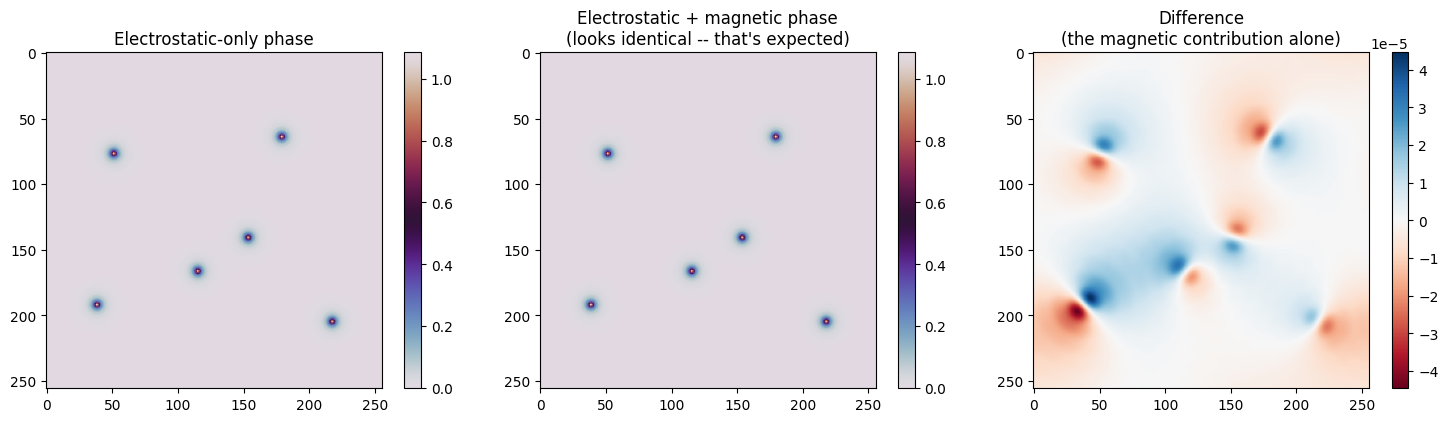

In [4]:
T_mag = fe_structure.make_transmission_functions(
    pixels, eV, displacements=False, include_magnetic=True
).cpu().numpy()
T_elec = fe_structure.make_transmission_functions(
    pixels, eV, displacements=False, include_magnetic=False
).cpu().numpy()
print("transmission function shape:", T_mag.shape, "-- (nsubslices, Y, X)")

phase_mag = np.angle(T_mag[0])
phase_elec = np.angle(T_elec[0])
phase_diff = phase_mag - phase_elec
print(f"max phase difference (magnetic contribution): {np.abs(phase_diff).max():.3e} rad")

fig, ax = plt.subplots(ncols=3, figsize=(15, 4))
im0 = ax[0].imshow(phase_elec, cmap="twilight")
ax[0].set_title("Electrostatic-only phase")
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(phase_mag, cmap="twilight")
ax[1].set_title("Electrostatic + magnetic phase\n(looks identical -- that's expected)")
plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(phase_diff, cmap="RdBu", vmin=-np.abs(phase_diff).max(), vmax=np.abs(phase_diff).max())
ax[2].set_title("Difference\n(the magnetic contribution alone)")
plt.colorbar(im2, ax=ax[2])
plt.tight_layout()
plt.show()

## Example 3: effect on a propagated exit wave

Finally, we run a single-slice multislice calculation with and without the
magnetic contribution, using the ordinary `pyms.make_propagators` and
`pyms.multislice` functions (nothing magnetic-specific about either of
these -- the magnetic phase enters entirely through the transmission function
built in Example 2).

exit-wave phase difference: max = 4.462e-05 rad
diffraction-pattern intensity, relative difference: max = 0.19%


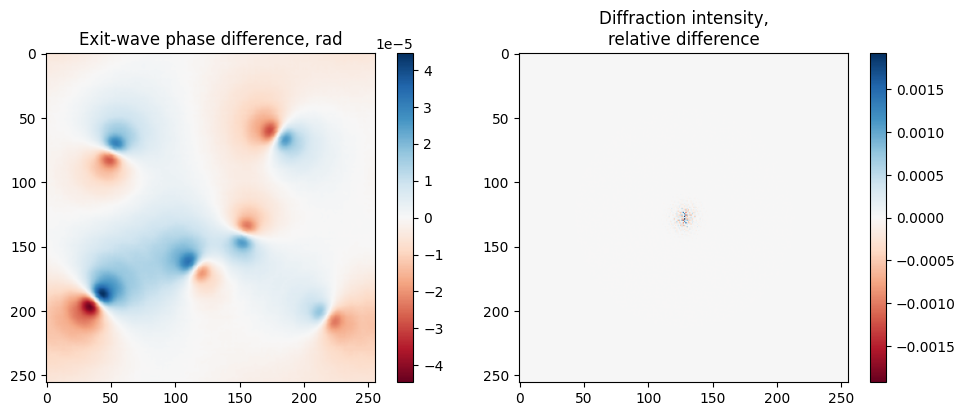

In [5]:
P = make_propagators(pixels, unitcell, eV, subslices=[1.0])
illum = plane_wave_illumination(pixels, unitcell[:2], eV)

# multislice() expects transmission_functions shaped (nT, nsubslices, Y, X);
# T_mag/T_elec are already (nsubslices, Y, X) = (1, Y, X), so we only need to
# add the leading nT=1 axis (a single, non-frozen-phonon transmission function).
psi_mag = multislice(illum, 1, P, T_mag[None], output_to_bandwidth_limit=False)
psi_elec = multislice(illum, 1, P, T_elec[None], output_to_bandwidth_limit=False)

exit_phase_diff = np.angle(psi_mag) - np.angle(psi_elec)
print(f"exit-wave phase difference: max = {np.abs(exit_phase_diff).max():.3e} rad")

I_mag = np.abs(np.fft.fftshift(np.fft.fft2(psi_mag))) ** 2
I_elec = np.abs(np.fft.fftshift(np.fft.fft2(psi_elec))) ** 2
diffraction_rel_diff = (I_mag - I_elec) / np.maximum(I_elec, I_elec.max() * 1e-6)
print(f"diffraction-pattern intensity, relative difference: max = {np.abs(diffraction_rel_diff).max():.2%}")

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
im0 = ax[0].imshow(exit_phase_diff, cmap="RdBu",
                    vmin=-np.abs(exit_phase_diff).max(), vmax=np.abs(exit_phase_diff).max())
ax[0].set_title("Exit-wave phase difference, rad")
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(diffraction_rel_diff, cmap="RdBu",
                    vmin=-np.abs(diffraction_rel_diff).max(), vmax=np.abs(diffraction_rel_diff).max())
ax[1].set_title("Diffraction intensity,\nrelative difference")
plt.colorbar(im1, ax=ax[1])
plt.tight_layout()
plt.show()

The exit-wave phase difference reproduces the same four-lobed dipole pattern
from Example 1 (as expected for a single thin slice, where the transmission
function's phase is imprinted directly onto the wave). The diffraction-pattern
intensity difference, by contrast, is tiny (well under 1% even at its
strongest, and concentrated near the direct beam) -- this is a real, physically
expected feature of the weak-phase-object regime a magnetic phase shift this
small sits in, **not** a sign that the feature isn't working. A phase this
small changes the diffracted *amplitude* only at second order; it is exactly
why real experimental detection of this effect relies on phase-sensitive
techniques (differential phase contrast, holography) rather than plain
bright-field/diffraction intensity -- see Edstrom, Lubk & Rusz, *Quantum
mechanical treatment of atomic-resolution differential phase contrast imaging
of magnetic materials*, Phys. Rev. B 99, 174428 (2019).

## Backward compatibility

Every one of these calls degrades gracefully to ordinary, non-magnetic PyMS
behaviour: omit `magnetic_moments` (or pass `magnetic_moments=None`, the
default) and `structure.is_magnetic` is `False`, `make_transmission_functions`
returns exactly the pre-existing electrostatic-only transmission function
regardless of `include_magnetic`, and every existing, non-magnetic script or
notebook in this repository is completely unaffected.